Veriler yükleniyor...
Skorlar hesaplanıyor, lütfen bekleyin...
EER Değeri: 0.0292
Eşik Değeri: 0.776


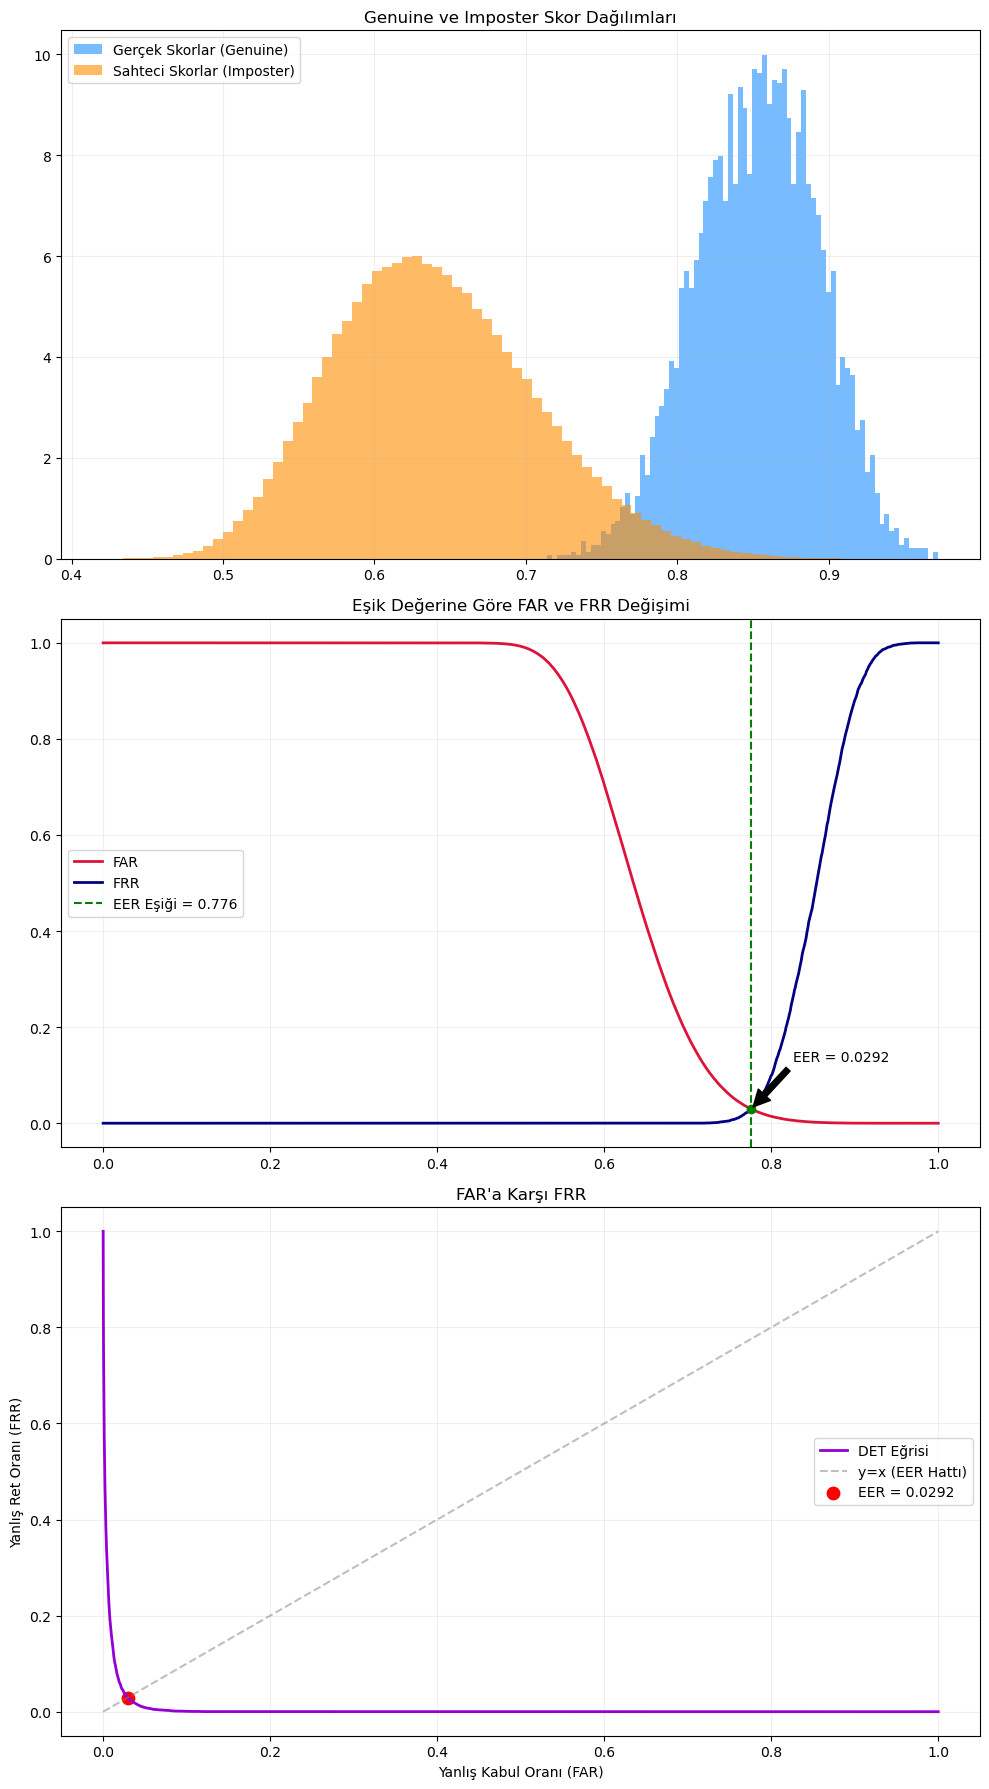

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean

# 1. VERİ YÜKLEME VE İLK 100 KİŞİ 
try:
    print("Veriler yükleniyor...")
    data = np.load('Features.npz')
    features = data['Features']
    features = features[:, :100, :] 
except FileNotFoundError:
    print("Hata: 'Features.npz' dosyası bulunamadı!")
    exit()

# 2. NORMALİZASYON [0, 1] 
f_min = features.min(axis=(0, 1), keepdims=True)
f_max = features.max(axis=(0, 1), keepdims=True)
features_norm = (features - f_min) / (f_max - f_min)

# 3. SKOR HESAPLAMA 
# Formül: 1 / (1 + Öklid Mesafesi) 
genuine_scores = []
imposter_scores = []

print("Skorlar hesaplanıyor, lütfen bekleyin...")

for i in range(100):
    for t1 in range(10):
        # Gerçek Skorlar (Genuine) 
        for t2 in range(t1 + 1, 10):
            dist = euclidean(features_norm[t1, i], features_norm[t2, i])
            genuine_scores.append(1 / (1 + dist))
        
        # Sahteci Skorlar (Imposter) 
        for j in range(i + 1, 100):
            for t2 in range(10):
                dist = euclidean(features_norm[t1, i], features_norm[t2, j])
                imposter_scores.append(1 / (1 + dist))

genuine_scores = np.array(genuine_scores)
imposter_scores = np.array(imposter_scores)

# 4. FAR, FRR VE EER HESABI 
thresholds = np.linspace(0, 1, 1000)
far_list = np.array([np.sum(imposter_scores >= t) / len(imposter_scores) for t in thresholds])
frr_list = np.array([np.sum(genuine_scores < t) / len(genuine_scores) for t in thresholds])

# EER ve Eşik değerini bul 
idx = np.nanargmin(np.abs(far_list - frr_list))
eer = (far_list[idx] + frr_list[idx]) / 2
eer_threshold = thresholds[idx]

print(f"EER Değeri: {eer:.4f}")
print(f"Eşik Değeri: {eer_threshold:.3f}")

# 5. GRAFİKLER 
plt.figure(figsize=(10, 18))

# Grafik 1: Dağılımlar  
plt.subplot(3, 1, 1)
plt.hist(genuine_scores, bins=80, alpha=0.6, color='dodgerblue', label='Gerçek Skorlar (Genuine)', density=True)
plt.hist(imposter_scores, bins=80, alpha=0.6, color='darkorange', label='Sahteci Skorlar (Imposter)', density=True)
plt.title('Genuine ve Imposter Skor Dağılımları')
plt.legend()
plt.grid(True, alpha=0.2)

# Grafik 2: FAR-FRR-EER 
plt.subplot(3, 1, 2)
plt.plot(thresholds, far_list, color='crimson', label='FAR', linewidth=2)
plt.plot(thresholds, frr_list, color='navy', label='FRR', linewidth=2)
plt.axvline(eer_threshold, color='green', linestyle='--', label=f'EER Eşiği = {eer_threshold:.3f}')
plt.plot(eer_threshold, eer, 'go')
plt.annotate(f'EER = {eer:.4f}', xy=(eer_threshold, eer), xytext=(eer_threshold+0.05, eer+0.1),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
plt.title('Eşik Değerine Göre FAR ve FRR Değişimi')
plt.legend()
plt.grid(True, alpha=0.2)

# Grafik 3: DET Eğrisi 
plt.subplot(3, 1, 3)
plt.plot(far_list, frr_list, color='darkviolet', lw=2, label='DET Eğrisi')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5, label='y=x (EER Hattı)')
plt.scatter(eer, eer, color='red', s=80, label=f'EER = {eer:.4f}')
plt.title("FAR'a Karşı FRR")
plt.xlabel('Yanlış Kabul Oranı (FAR)')
plt.ylabel('Yanlış Ret Oranı (FRR)')
plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('odev_sonuc_3grafik.png', dpi=300)
plt.show()